In [1]:
from astropy.io import fits
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import curve_fit
import itertools

Final Mean of all bias frames: 1005.7920463924132
RMS of STDs: 17.05
Read Out Noise (RON): 12.06


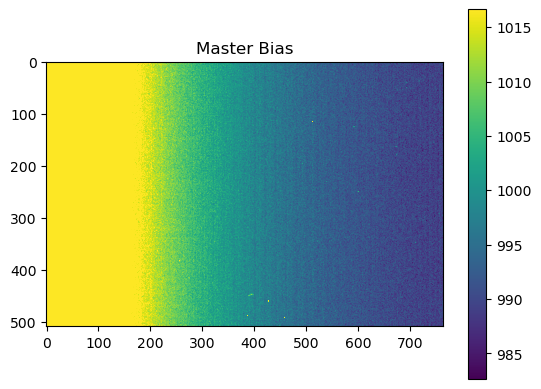

In [2]:
# Initialize variables
biasimages = []
bias_shape = (510, 765)  # Assuming these are the correct dimensions
bias_accumulator = np.zeros(bias_shape)  # Accumulate pixel values for master bias

# Loop through FITS files
for i in range(20):
    filename = f"pyobs-20240528-0{685+i:03d}-b00.fits"
    try:
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]  # Access the primary HDU
            data = hdu.data.astype(np.float32)  # Ensure consistent data type
            biasimages.append(data)  # Append current bias frame to the list
            bias_accumulator += data  # Accumulate data for master bias
    except FileNotFoundError:
        print(f"File {filename} not found.")
    except Exception as e:
        print(f"Error loading file {filename}: {e}")

# Ensure we have loaded images
if not biasimages:
    raise ValueError("No bias images loaded.")

# Calculate the master bias
masterbias = bias_accumulator / len(biasimages)

# Final Mean of all bias frames
final_mean = np.mean(masterbias)
print('Final Mean of all bias frames:', final_mean)

# Generate all possible pairs of bias frames
combinations = itertools.combinations(biasimages, 2)

std_devs = []  # List to store standard deviations of differences

# Compute difference images and their standard deviations
for img1, img2 in combinations:
    diff = img1 - img2  # Subtract one image from another
    std_dev = np.std(diff)  # Compute standard deviation
    std_devs.append(std_dev)

# Compute RMS of the 190 standard deviations
if std_devs:
    rms_std = np.sqrt(np.mean(np.square(std_devs)))  # RMS of standard deviations
    read_out_noise = rms_std / np.sqrt(2)  # Compute RON
    print(f"RMS of STDs: {rms_std:.2f}")
    print(f"Read Out Noise (RON): {read_out_noise:.2f}")
else:
    print("No standard deviation values calculated. Check the images.")

# Data visualization
med, sigma_visual = np.median(masterbias), np.std(masterbias)
plt.imshow(masterbias, vmin=med - sigma_visual, vmax=med + sigma_visual, cmap='viridis')
plt.title('Master Bias')
plt.colorbar()
plt.show()

In [7]:
len(std_devs)

190

In [8]:
bias=masterbias

In [9]:
#check combinations
combinations = list(itertools.combinations(biasimages, 2))
print(len(combinations))

190


In [10]:
img1

array([[1053., 1059., 1060., ...,  970.,  993., 1001.],
       [1048., 1064., 1046., ...,  975.,  989., 1006.],
       [1062., 1054., 1073., ...,  984.,  989.,  978.],
       ...,
       [1053., 1060., 1053., ...,  988., 1008., 1006.],
       [1066., 1046., 1029., ..., 1002.,  950.,  995.],
       [1052., 1045., 1057., ...,  981.,  984.,  987.]], dtype=float32)

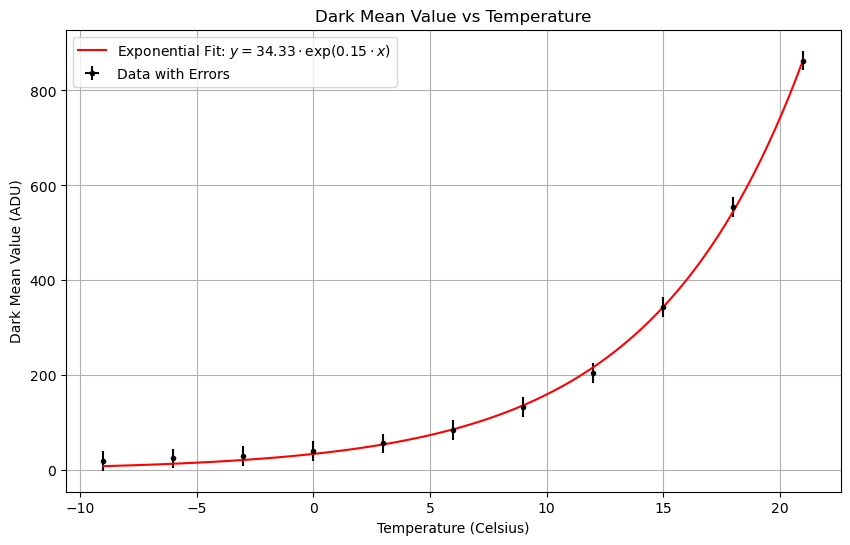

a * exp(b * x), fitted parameters: a = 34.32910176617205, b = 0.1536796888152454


In [11]:
Mean=0
ADU = np.zeros(11)
Temp = np.zeros(11)
Sigma = np.zeros(11)
for i in range(11):
    filename = f"pyobs-20240528-0{669+i:03d}-d00.fits"
    with fits.open(filename) as hdulist:
        hdu = hdulist[0]
        mean=np.mean(hdu.data)-np.mean(bias)
        ADU[i]=mean
        Temp[i] = 21-3*i
        Sigma[i] = np.std(data)
# Define an exponential function
def exponential_func(x, a, b):
    return a * np.exp(b * x)

# Fit the exponential function to your data
popt, pcov = curve_fit(exponential_func, Temp, ADU)

# Extract the fitted parameters
a_fit, b_fit = popt

# Generate points for the fitted curve
Temp_fit = np.linspace(min(Temp), max(Temp), 100)
ADU_fit = exponential_func(Temp_fit, a_fit, b_fit)



# Plotting with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(Temp, ADU, yerr=Sigma, xerr=0.1, fmt='.', color='black', label='Data with Errors')
plt.plot(Temp_fit, ADU_fit, color='red', linestyle='-', label='Exponential Fit: '+rf'$y = {a_fit:.2f} \cdot \exp({b_fit:.2f} \cdot x)$')

# Add titles and labels
plt.title('Dark Mean Value vs Temperature')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Dark Mean Value (ADU)')



# Add a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()
print(f"a * exp(b * x), fitted parameters: a = {a_fit}, b = {b_fit}")

average dark:  [[ 42.15  31.5   27.35 ...  49.6   29.8  143.95]
 [ 35.65  18.15  26.8  ...  29.25   7.2   28.45]
 [ 28.3   30.95  16.2  ...  37.3   35.15  34.9 ]
 ...
 [ 23.6   28.65  31.6  ...  18.    30.65  18.45]
 [ 23.65  22.55  33.35 ...  11.95  31.    20.85]
 [ 25.9   40.35  20.45 ...  16.3   24.55  23.6 ]]


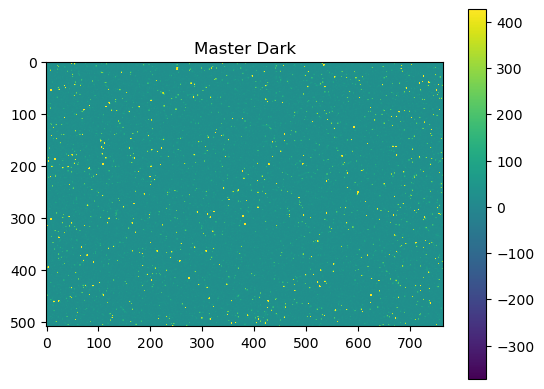

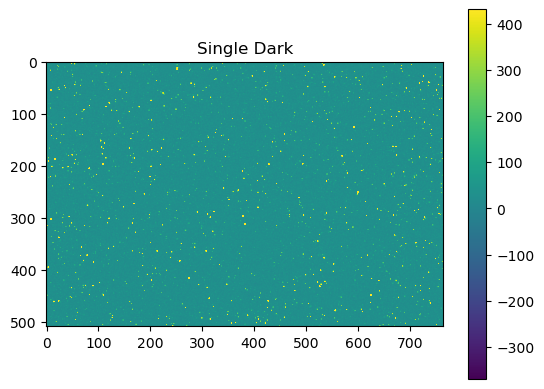

36.825177239523256 40.21045520953481 399.52400347432246 400.74911206979215
RMS noise (residuals from mean):  399.52400347432246


In [12]:
#average dark
Mean=0
dark = np.zeros((510, 765))
for i in range(5):
    filename = f"pyobs-20240528-0{680+i:03d}-d00.fits"
    with fits.open(filename) as hdulist:
        hdu = hdulist[0]
        mean=np.mean(hdu.data)
        for j in range(510):
            for k in range(765):
                dark[j][k] +=  hdu.data[j][k]

        Mean+=mean
dark-=5*bias
dark/=5
print('average dark: ', dark)

data = dark
med,sigma = np.median(data),np.std(data)
plt.title('Master Dark')
plt.imshow (data,vmin = med - sigma , vmax = med + sigma )
plt.colorbar ()
plt.show ()

data1 = fits.getdata ("pyobs-20240528-0676-d00.fits")-bias
med1,sigma1 = np.median(data1),np.std(data1)
plt.title('Single Dark')
plt.imshow (data1,vmin = med1 - sigma1 , vmax = med1 + sigma1 )
plt.colorbar ()
plt.show ()
print(np.mean(data),np.mean(data1),sigma,sigma1)
# Calculate RMS of residuals from the mean (another measure of noise)
noise_rms = np.sqrt(np.mean((data - np.mean(data))**2))
print('RMS noise (residuals from mean): ', noise_rms)

Final Mean of all dark frames: 36.825177239523256


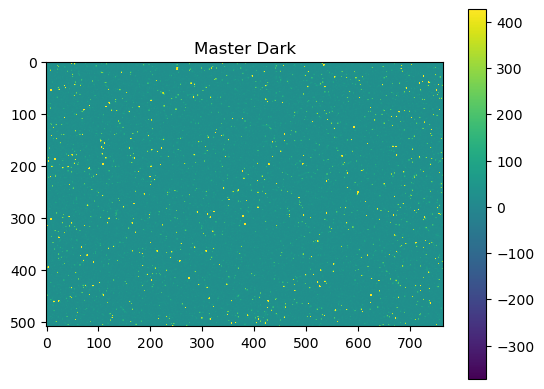

Sigma for Dark Frame 1: 18.60
Sigma for Dark Frame 2: 18.57
Sigma for Dark Frame 3: 24.56
Sigma for Dark Frame 4: 21.11
Sigma for Dark Frame 5: 24.14


In [13]:
# Initialize variables
darkimages = []
dark_shape = (510, 765)  # Assuming these are the correct dimensions
dark_accumulator = np.zeros(dark_shape)  # Accumulate pixel values for master dark

# Loop through FITS files
for i in range(5):
    filename = f"pyobs-20240528-0{680+i:03d}-d00.fits"
    try:
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]  # Access the primary HDU
            data = hdu.data.astype(np.float32)-masterbias  # Ensure consistent data type
            darkimages.append(data)  # Append current dark frame to the list
            dark_accumulator += data  # Accumulate data for master dark
    except FileNotFoundError:
        print(f"File {filename} not found.")
    except Exception as e:
        print(f"Error loading file {filename}: {e}")

# Ensure we have loaded images
if not darkimages:
    raise ValueError("No dark images loaded.")

# Calculate the master dark
masterdark = dark_accumulator / len(darkimages)

# Final Mean of all dark frames
final_mean = np.mean(masterdark)
print('Final Mean of all dark frames:', final_mean)

# Generate all possible pairs of dark frames
combinations = itertools.combinations(darkimages, 2)

# Empty list to store the variances
variance = []
mean_differences = []  # To store mean differences for each pair

# Calculate the variance for each pair of dark frames
for img1, img2 in combinations:
    diff = img1 - img2  # Difference between the two images
    mean_diff = np.mean(diff)  # Mean of the difference
    var = np.var(diff)  # Variance of the difference
    
    # Append results to lists
    mean_differences.append(mean_diff)
    variance.append(var)



# Data visualization
med, sigma_visual = np.median(masterdark), np.std(masterdark)
plt.imshow(masterdark, vmin=med - sigma_visual, vmax=med + sigma_visual, cmap='viridis')
plt.title('Master Dark')
plt.colorbar()
plt.show()

for i, data in enumerate(darkimages):
    diff = data - masterdark  # Difference between the frame and master dark
    frame_sigma = np.std(diff)  # Standard deviation of the difference
    print(f"Sigma for Dark Frame {i + 1}: {frame_sigma:.2f}")

In [14]:
dark=masterdark

Mean value of flat 1 :  4233.466908624888


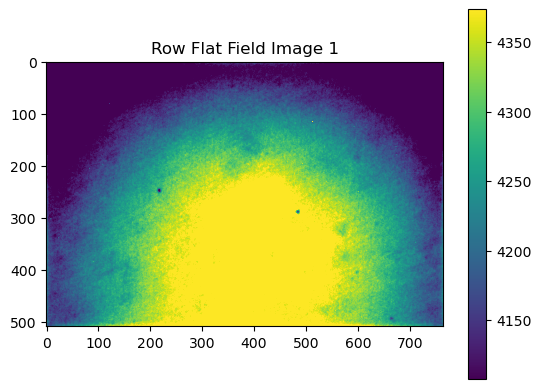

RMS of flat 1:  132.802363704397
Mean value of flat 2 :  7439.087240975691


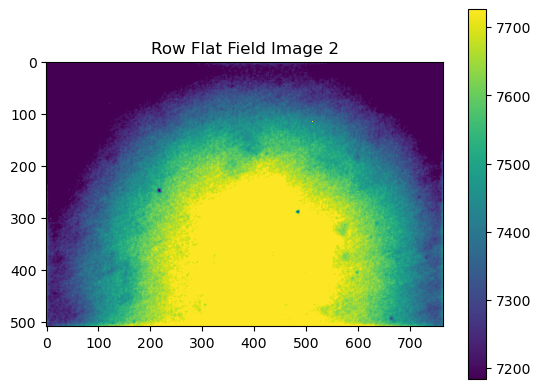

RMS of flat 2:  270.9826444063922
Mean value of flat 3 :  13851.876555854584


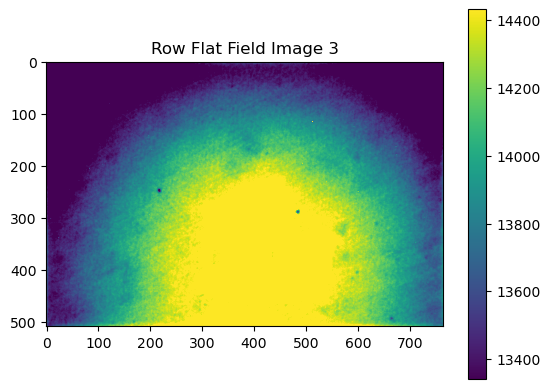

RMS of flat 3:  545.3349309700961
Mean value of flat 4 :  26629.79015165108


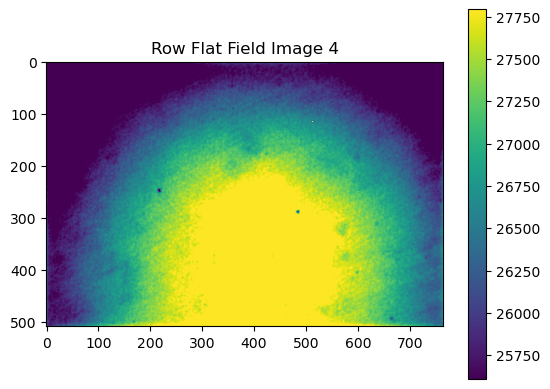

RMS of flat 4:  1091.9214329916915
Mean value of flat 5 :  39347.56975300099


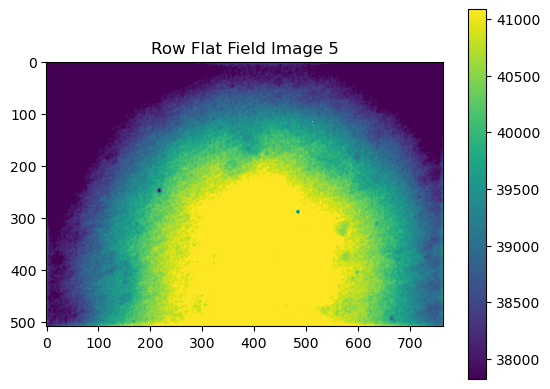

RMS of flat 5:  1632.322055935097
Mean value of flat 6 :  51998.794212994995


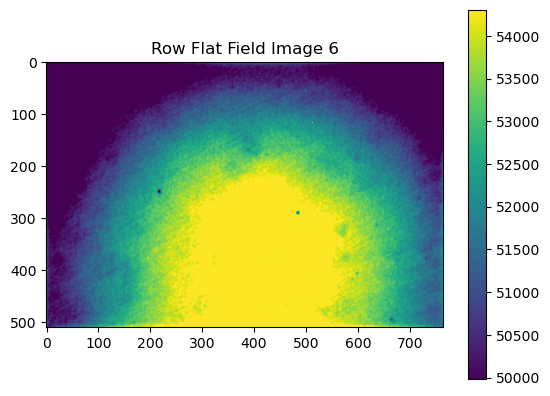

RMS of flat 6:  2163.556305589515
Mean value of flat 7 :  63893.73802332436


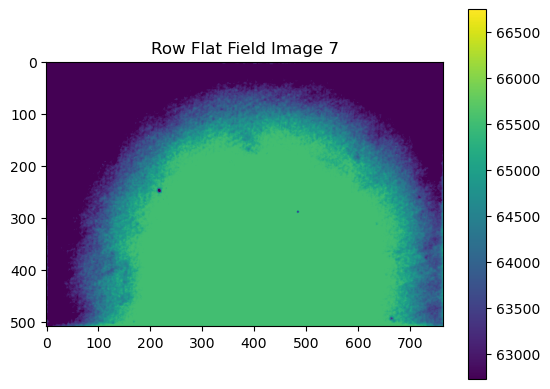

RMS of flat 7:  2012.2479923733108


In [15]:
from sklearn.linear_model import LinearRegression

flat = [np.zeros((510, 765)) for _ in range(7)]
Meanflat = np.zeros(7)
Exptime = np.zeros(7)
VarianceFlat=np.zeros(7)
for l in range(7):
    Mean=0    
    for i in range(15):

        filename = f"pyobs-20240528-0{705+l*15+i:03d}-f00.fits"
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]
            data = hdu.data
            mean = np.mean(data)
            flat[l] += data  # Use vectorized addition
            Mean += mean
            Meanflat[l]= Mean / 15
            Exptime[l]=hdu.header['EXPTIME']
    flat[l] /= 15  # Average the accumulated data
    print('Mean value of flat', l+1, ': ', Mean / 15)

    data = flat[l]
    med, sigma = np.median(data), np.std(data)
    
    rms = np.sqrt(np.mean(np.square(data)))
    
    VarianceFlat[l]=np.var(flat[l])
    plt.imshow(data, vmin=med - sigma, vmax=med + sigma)
    plt.colorbar()
    plt.title(f'Row Flat Field Image {l+1}')
    plt.show()
    print(f'RMS of flat {l+1}: ', sigma)

Mean value of flat 1 :  3227.674862232475


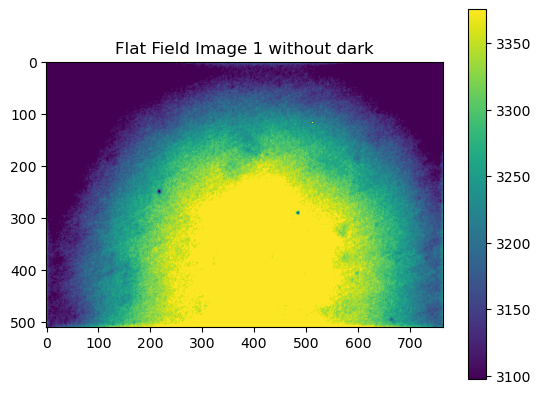

RMS of flat 1:  139.07300989988724
Mean value of flat 2 :  6433.29519458328


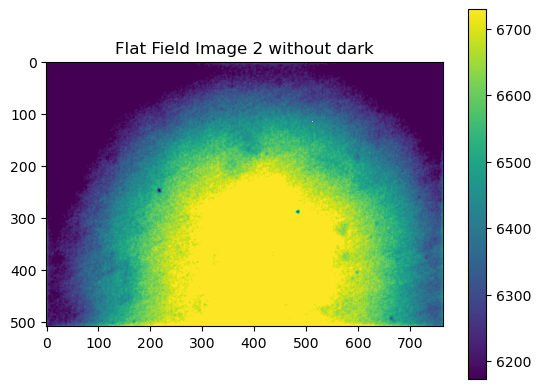

RMS of flat 2:  277.8667302912006
Mean value of flat 3 :  12846.084509462173


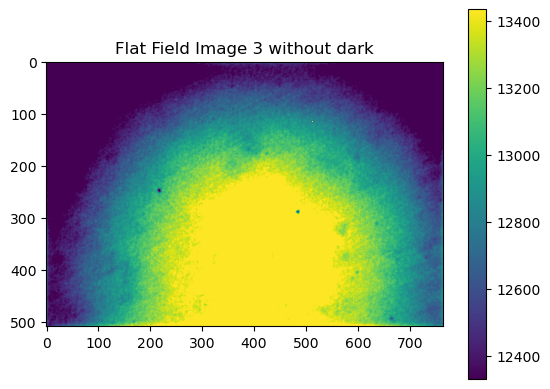

RMS of flat 3:  552.5244644651941
Mean value of flat 4 :  25623.998105258655


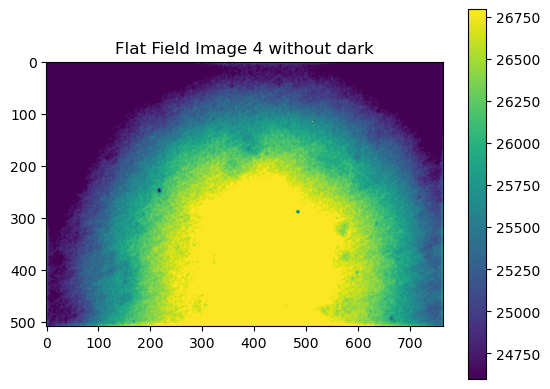

RMS of flat 4:  1099.2573091692993
Mean value of flat 5 :  38341.777706608555


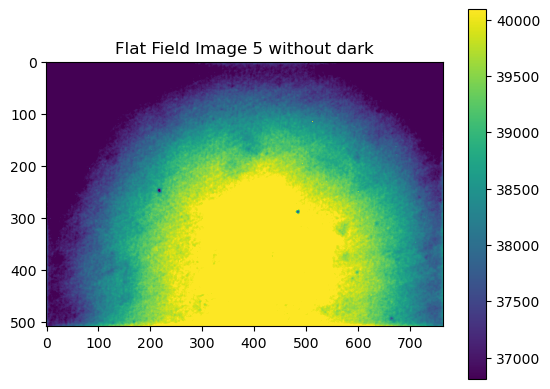

RMS of flat 5:  1639.7087201886097
Mean value of flat 6 :  50993.00216660259


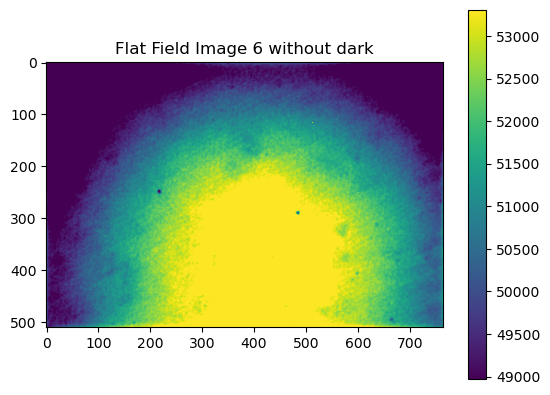

RMS of flat 6:  2170.9677599962447
Mean value of flat 7 :  62887.945976931966


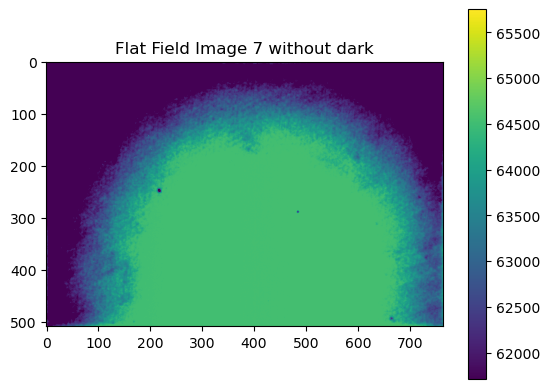

RMS of flat 7:  2019.8645330383124


In [16]:
flat = [np.zeros((510, 765)) for _ in range(7)]
Meanflat = np.zeros(7)
Exptime = np.zeros(7)
for l in range(7):
    Mean=0    
    for i in range(15):

        filename = f"pyobs-20240528-0{705+l*15+i:03d}-f00.fits"
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]
            data = hdu.data-bias
            mean = np.mean(data)
            flat[l] += data  # Use vectorized addition
            Mean += mean
            Meanflat[l]= Mean / 15
            Exptime[l]=hdu.header['EXPTIME']
    flat[l] /= 15  # Average the accumulated data
    print('Mean value of flat', l+1, ': ', Mean / 15)

    data = flat[l]
    rms = np.sqrt(np.mean(np.square(data)))
    med, sigma = np.median(data), np.std(data)
    plt.imshow(data, vmin=med - sigma, vmax=med + sigma)
    plt.colorbar()
    plt.title(f'Flat Field Image {l+1} without dark')
    plt.show()
    print(f'RMS of flat {l+1}: ', sigma)

Mean value of flat 1 :  3227.552111641676


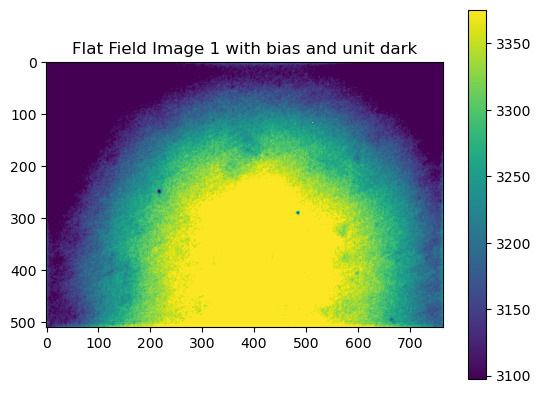

RMS of flat 1:  139.0624892424621
Mean value of flat 2 :  6433.049693401682


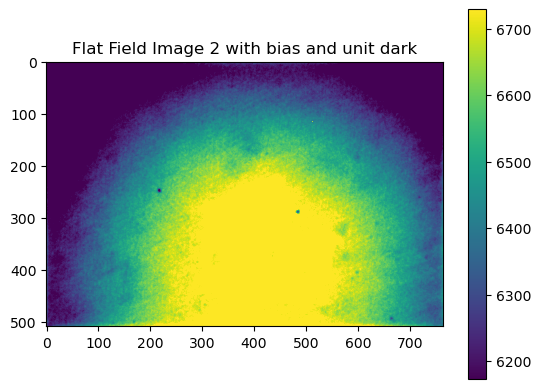

RMS of flat 2:  277.8465883617849
Mean value of flat 3 :  12845.593507098978


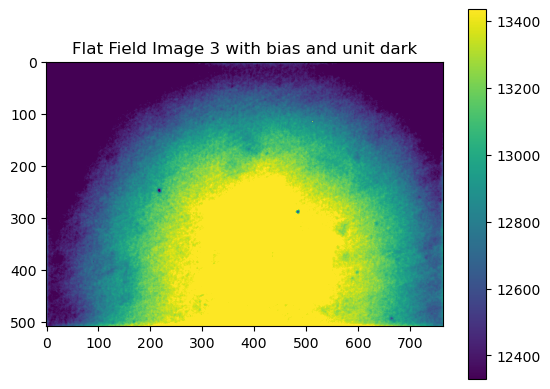

RMS of flat 3:  552.488970692882
Mean value of flat 4 :  25623.016100532277


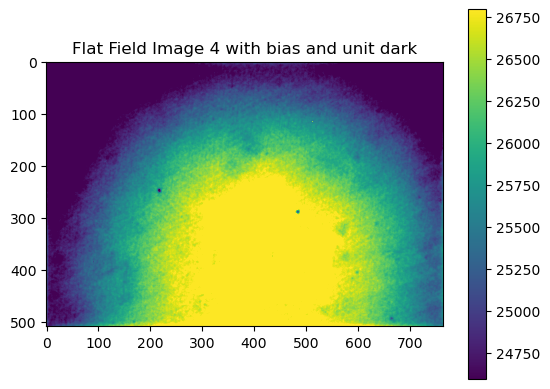

RMS of flat 4:  1099.1938974585064
Mean value of flat 5 :  38340.30469951898


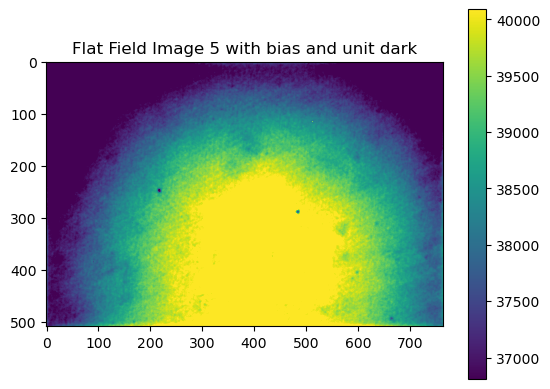

RMS of flat 5:  1639.6247037607945
Mean value of flat 6 :  50991.038157149815


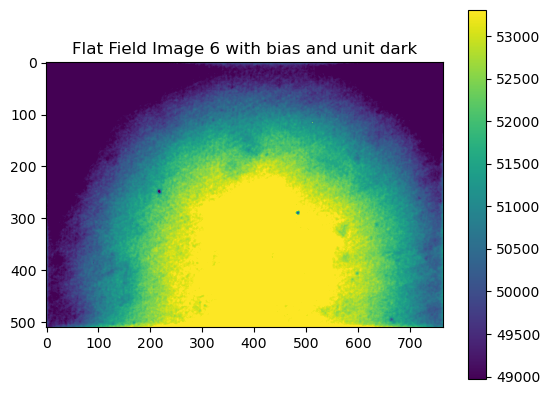

RMS of flat 6:  2170.8750198851576
Mean value of flat 7 :  62885.490965115976


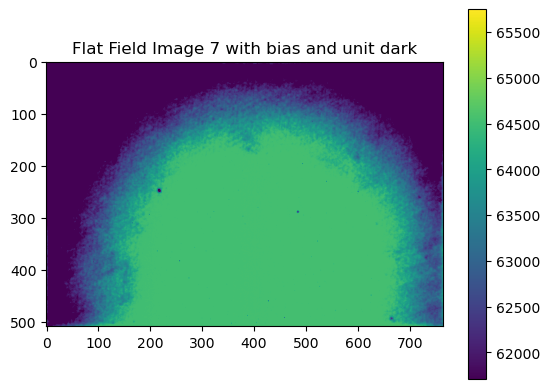

RMS of flat 7:  2019.9626315268758


In [17]:
flat = [np.zeros((510, 765)) for _ in range(7)]
Meanflat = np.zeros(7)
Exptime = np.zeros(7)
for l in range(7):
    Mean=0    
    for i in range(15):

        filename = f"pyobs-20240528-0{705+l*15+i:03d}-f00.fits"
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]
            data = hdu.data-bias-dark*hdu.header['EXPTIME']/300
            mean = np.mean(data)
            flat[l] += data  # Use vectorized addition
            Mean += mean
            Meanflat[l]= Mean / 15
            Exptime[l]=hdu.header['EXPTIME']
    flat[l] /= 15  # Average the accumulated data
    print('Mean value of flat', l+1, ': ', Mean / 15)

    data = flat[l]
    med, sigma = np.median(data), np.std(data)
    rms = np.sqrt(np.mean(np.square(data)))
    plt.imshow(data, vmin=med - sigma, vmax=med + sigma)
    plt.colorbar()
    plt.title(f'Flat Field Image {l+1} with bias and unit dark')
    plt.show()
    print(f'RMS of flat {l+1}: ', sigma)
FLAT=flat[4]/Meanflat[4]

Mean value of flat 1 :  4233.344158034089


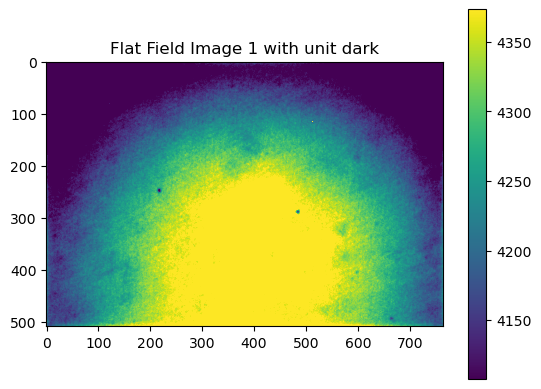

RMS of flat 1:  132.78568261337648
Mean value of flat 2 :  7438.841739794097


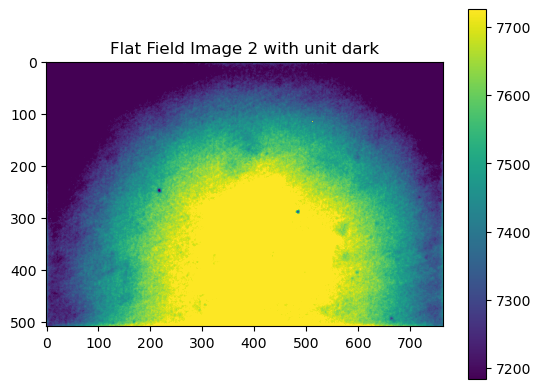

RMS of flat 2:  270.956439618808
Mean value of flat 3 :  13851.385553491391


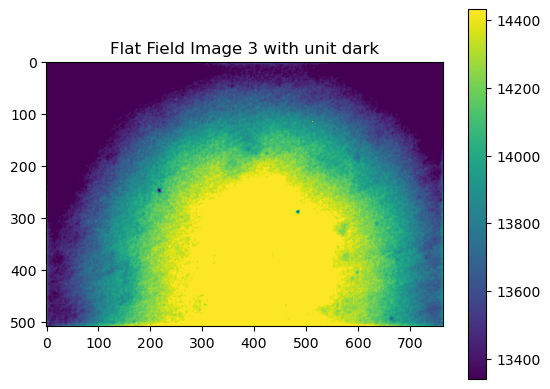

RMS of flat 3:  545.2934524827976
Mean value of flat 4 :  26628.808146924686


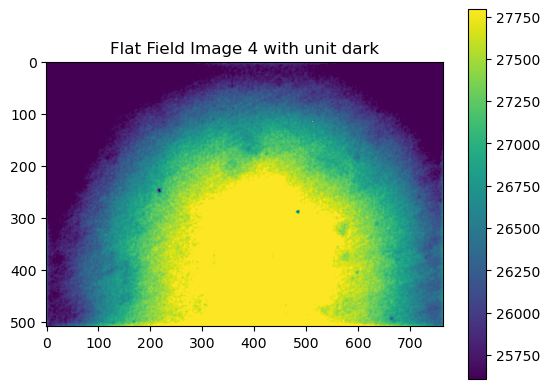

RMS of flat 4:  1091.852084869539
Mean value of flat 5 :  39346.0967459114


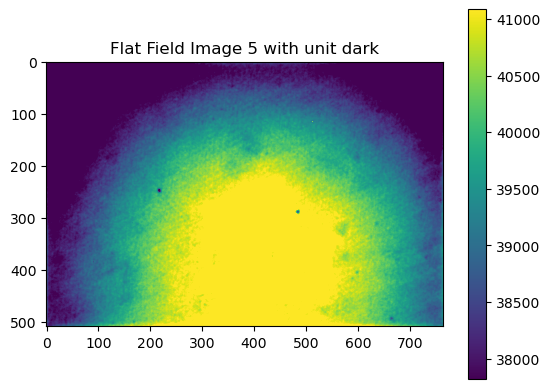

RMS of flat 5:  1632.2321301982272
Mean value of flat 6 :  51996.830203542224


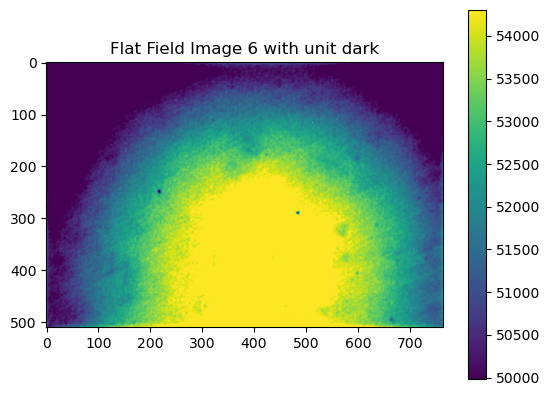

RMS of flat 6:  2163.4576858337905
Mean value of flat 7 :  63891.283011508385


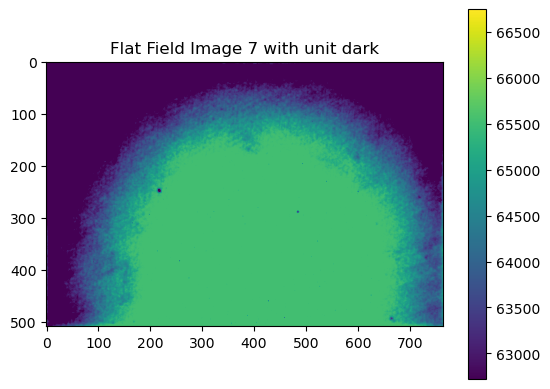

RMS of flat 7:  2012.3389876330255


In [18]:
flat = [np.zeros((510, 765)) for _ in range(7)]
Meanflat = np.zeros(7)
Exptime = np.zeros(7)
for l in range(7):
    Mean=0    
    for i in range(15):

        filename = f"pyobs-20240528-0{705+l*15+i:03d}-f00.fits"
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]
            data = hdu.data-dark*hdu.header['EXPTIME']/300 
            mean = np.mean(data)
            flat[l] += data  # Use vectorized addition
            Mean += mean
            Meanflat[l]= Mean / 15
            Exptime[l]=hdu.header['EXPTIME']
    flat[l] /= 15  # Average the accumulated data
    print('Mean value of flat', l+1, ': ', Mean / 15)

    data = flat[l]
    med, sigma = np.median(data), np.std(data)
    rms = np.sqrt(np.mean(np.square(data)))
    plt.imshow(data, vmin=med - sigma, vmax=med + sigma)
    plt.colorbar()
    plt.title(f'Flat Field Image {l+1} with unit dark')
    plt.show()
    print(f'RMS of flat {l+1}: ', sigma)
FLAT=flat[4]/Meanflat[4]

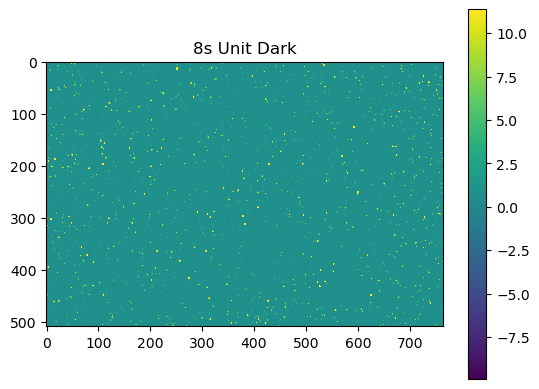

0.982004726387287 10.653973425981935


In [19]:
data = dark/300*8
med,sigma = np.median(data),np.std(data)
plt.title('8s Unit Dark')
plt.imshow (data,vmin = med - sigma , vmax = med + sigma )
plt.colorbar ()
plt.show ()
print(np.mean(data),sigma)

eightsec average dark:  [[51.35 38.4  25.75 ... 45.5  40.5  33.95]
 [28.45 26.25 21.5  ... 30.65 27.7  29.85]
 [27.3  37.25 30.   ... 28.2  37.65 27.7 ]
 ...
 [31.9  38.25 32.8  ... 27.1  29.15 22.75]
 [33.25 34.85 37.95 ... 20.65 39.7  37.75]
 [26.2  34.55 25.75 ... 39.2  25.15 35.  ]]


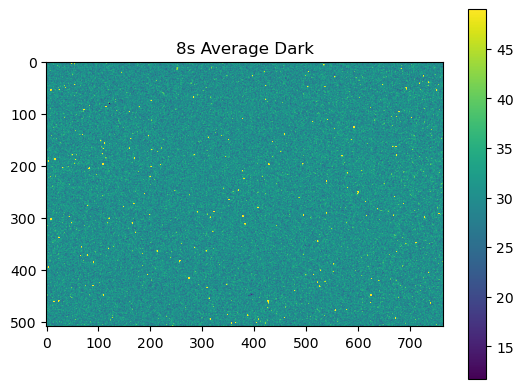

30.35 18.629076345108672


In [20]:
#eightsec average dark
Mean=0
eightsecdark = np.zeros((510, 765))
for i in range(10):
    filename = f"pyobs-20240124-00{41+i}-d00.fits"
    with fits.open(filename) as hdulist:
        hdu = hdulist[0]
        mean=np.mean(hdu.data)
        for j in range(510):
            for k in range(765):
                eightsecdark[j][k] +=  hdu.data[j][k]

        Mean+=mean
eightsecdark-=10*bias
eightsecdark/=10
print('eightsec average dark: ', eightsecdark)
data = eightsecdark
med,sigma = np.median(data),np.std(data)
plt.title('8s Average Dark')
plt.imshow (data,vmin = med - sigma , vmax = med + sigma )
plt.colorbar ()
plt.show ()
print(med,sigma)

Final Mean of all dark frames: 30.57912290144816


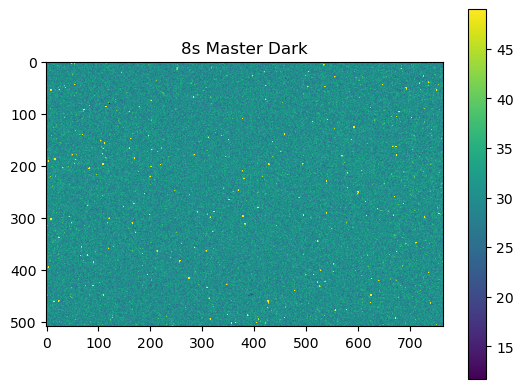

In [21]:
# Initialize variables
eightsecdarkimages = []
eightsecdark_shape = (510, 765)  # Assuming these are the correct dimensions
eightsecdark_accumulator = np.zeros(eightsecdark_shape)  # Accumulate pixel values for master dark

# Loop through FITS files
for i in range(10):
    filename =  f"pyobs-20240124-00{41+i}-d00.fits"
    try:
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]  # Access the primary HDU
            data = hdu.data.astype(np.float32)-masterbias  # Ensure consistent data type
            eightsecdarkimages.append(data)  # Append current dark frame to the list
            eightsecdark_accumulator += data  # Accumulate data for master dark
    except FileNotFoundError:
        print(f"File {filename} not found.")
    except Exception as e:
        print(f"Error loading file {filename}: {e}")

# Ensure we have loaded images
if not eightsecdarkimages:
    raise ValueError("No dark images loaded.")

# Calculate the master dark
mastereightsecdark = eightsecdark_accumulator / len(eightsecdarkimages)

# Final Mean of all dark frames
final_mean = np.mean(mastereightsecdark)
print('Final Mean of all dark frames:', final_mean)

# Generate all possible pairs of dark frames
combinations = itertools.combinations(eightsecdarkimages, 2)

# Empty list to store the variances
variance = []
mean_differences = []  # To store mean differences for each pair

# Calculate the variance for each pair of dark frames
for img1, img2 in combinations:
    diff = img1 - img2  # Difference between the two images
    mean_diff = np.mean(diff)  # Mean of the difference
    var = np.var(diff)  # Variance of the difference
    
    # Append results to lists
    mean_differences.append(mean_diff)
    variance.append(var)



# Data visualization
med, sigma_visual = np.median(mastereightsecdark), np.std(mastereightsecdark)
plt.imshow(mastereightsecdark, vmin=med - sigma_visual, vmax=med + sigma_visual, cmap='viridis')
plt.title('8s Master Dark')
plt.colorbar()
plt.show()

Mean value of flat 1 :  3197.095739331027


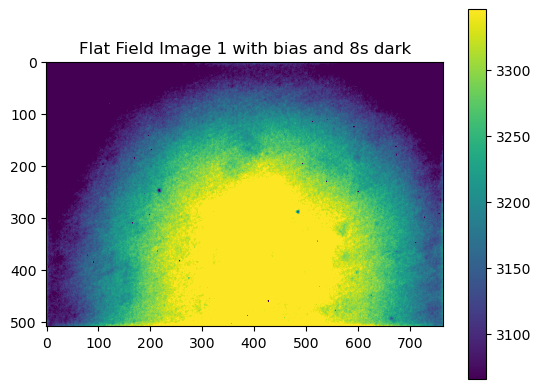

RMS of flat 1:  139.98000140377894
Mean value of flat 2 :  6402.7160716818335


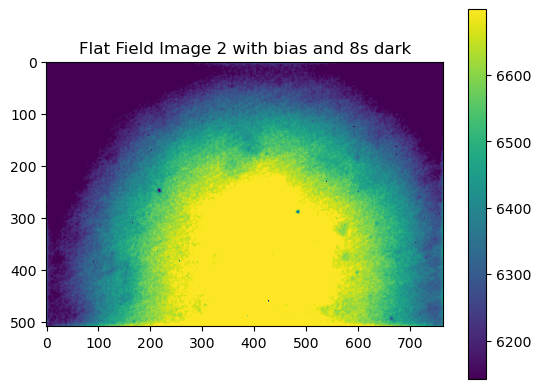

RMS of flat 2:  278.18172121102583
Mean value of flat 3 :  12815.50538656072


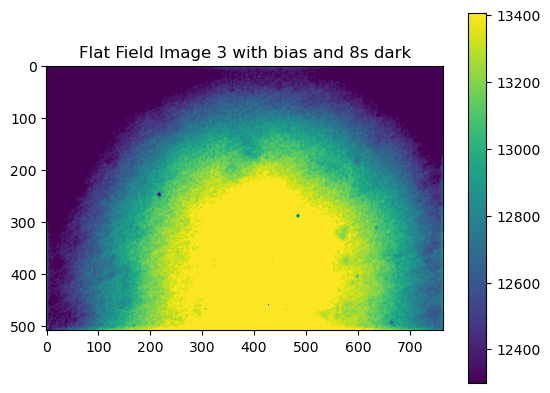

RMS of flat 3:  552.5624933624825
Mean value of flat 4 :  25593.418982357212


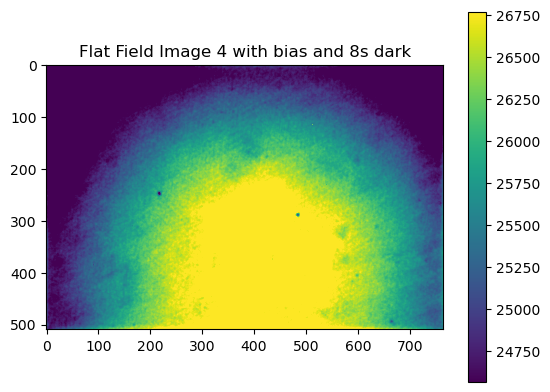

RMS of flat 4:  1099.163589631219
Mean value of flat 5 :  38311.198583707126


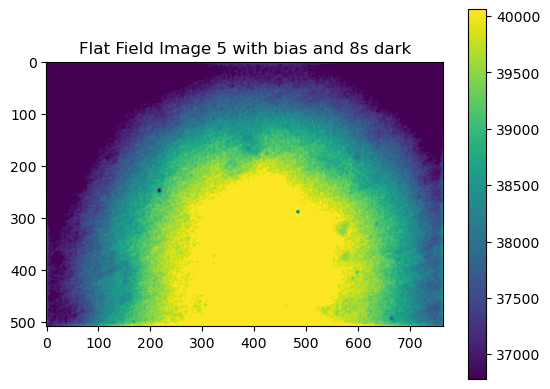

RMS of flat 5:  1639.5842625478488
Mean value of flat 6 :  50962.423043701165


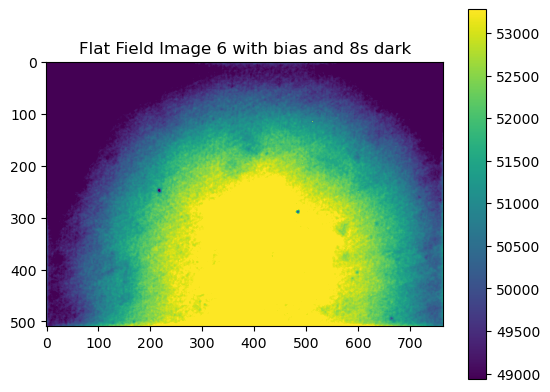

RMS of flat 6:  2170.850030616015
Mean value of flat 7 :  62857.36685403051


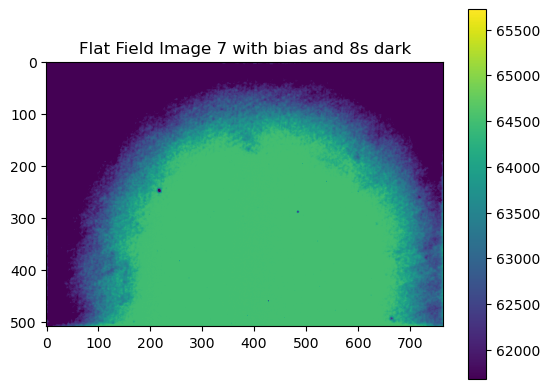

RMS of flat 7:  2019.9066071185653


In [22]:
flat = [np.zeros((510, 765)) for _ in range(7)]
Meanflat = np.zeros(7)
Exptime = np.zeros(7)
for l in range(7):
    Mean=0    
    for i in range(15):

        filename = f"pyobs-20240528-0{705+l*15+i:03d}-f00.fits"
        with fits.open(filename) as hdulist:
            hdu = hdulist[0]
            data = hdu.data-bias-eightsecdark 
            mean = np.mean(data)
            flat[l] += data  # Use vectorized addition
            Mean += mean
            Meanflat[l]= Mean / 15
            Exptime[l]=hdu.header['EXPTIME']
    flat[l] /= 15  # Average the accumulated data
    print('Mean value of flat', l+1, ': ', Mean / 15)

    data = flat[l]
    med, sigma = np.median(data), np.std(data)
    plt.imshow(data, vmin=med - sigma, vmax=med + sigma)
    plt.colorbar()
    plt.title(f'Flat Field Image {l+1} with bias and 8s dark')
    plt.show()
    print(f'RMS of flat {l+1}: ', sigma)
pureflat=flat[4]/Meanflat[4]#Normalization

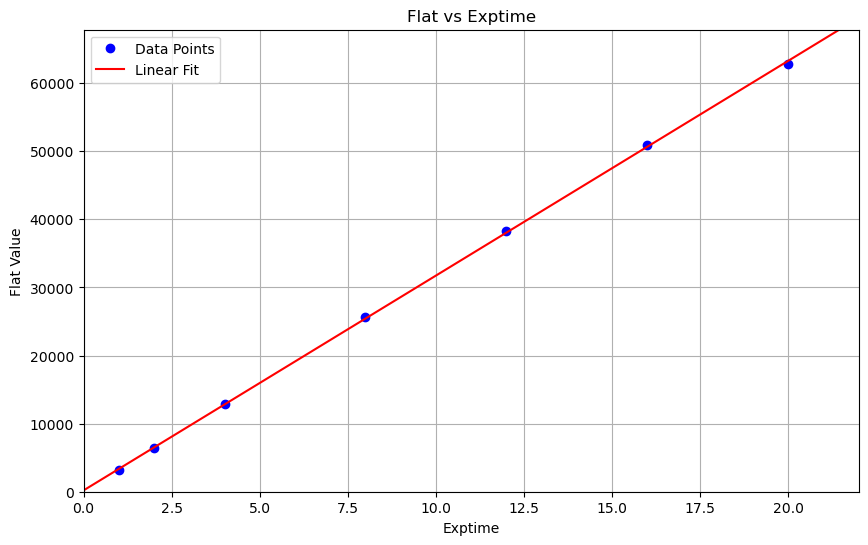

Slope: 3154.20
Intercept: 203.61
Standard Error: 15.83


In [23]:

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(Exptime, Meanflat)

# Generate values for the regression line
regression_x = np.linspace(0, Exptime.max() + 2, 100)
regression_y = slope * regression_x + intercept

# Calculate the error range
confidence_interval = 1.96 * std_err  # 95% confidence interval
regression_y_upper = regression_y + confidence_interval
regression_y_lower = regression_y - confidence_interval

# Plot the data and the regression line
plt.figure(figsize=(10, 6))
plt.plot(Exptime, Meanflat, color='blue', marker='o', linestyle='none', label='Data Points')
plt.plot(regression_x, regression_y, color='red', label='Linear Fit')


# Add titles and labels
plt.title('Flat vs Exptime')
plt.xlabel('Exptime')
plt.ylabel('Flat Value')

# Set the x and y axis limits to start from 0
plt.xlim(0, Exptime.max() + 2)
plt.ylim(0, max(Meanflat) + 5000)

# Add a legend
plt.legend()

# Show the plot
plt.grid(True)  # Add grid for better visualization


plt.show()

# Print the slope, intercept, and standard error
print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"Standard Error: {std_err:.2f}")

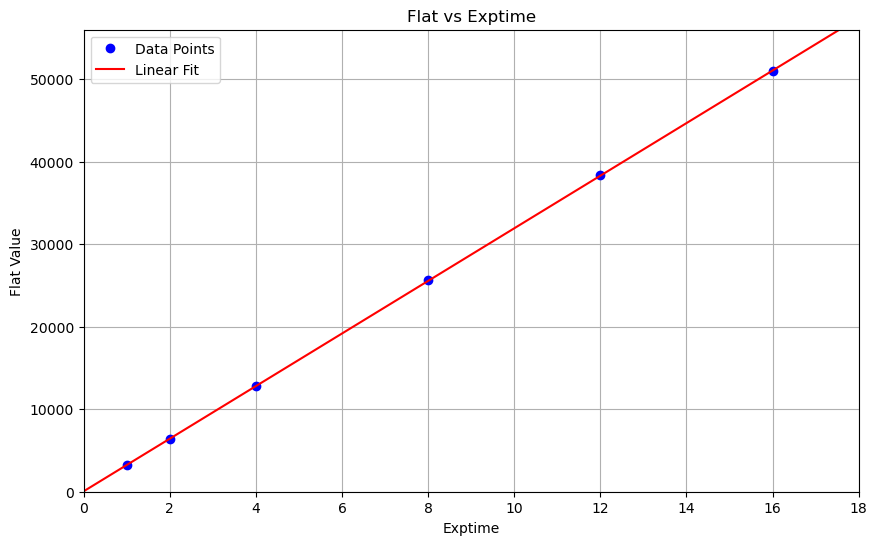

Slope: 3185.42
Intercept: 51.56
Standard Error: 3.80


In [24]:
Exptime = Exptime[:-1]
Meanflat = Meanflat[:-1]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(Exptime, Meanflat)

# Generate values for the regression line
regression_x = np.linspace(0, Exptime.max() + 2, 100)
regression_y = slope * regression_x + intercept

# Calculate the error range
confidence_interval = 1.96 * std_err  # 95% confidence interval
regression_y_upper = regression_y + confidence_interval
regression_y_lower = regression_y - confidence_interval

# Plot the data and the regression line
plt.figure(figsize=(10, 6))
plt.plot(Exptime, Meanflat, color='blue', marker='o', linestyle='none', label='Data Points')
plt.plot(regression_x, regression_y, color='red', label='Linear Fit')

# Add titles and labels
plt.title('Flat vs Exptime')
plt.xlabel('Exptime')
plt.ylabel('Flat Value')

# Set the x and y axis limits to start from 0
plt.xlim(0, Exptime.max() + 2)
plt.ylim(0, max(Meanflat) + 5000)

# Add a legend
plt.legend()

# Show the plot
plt.grid(True)  # Add grid for better visualization


plt.show()

# Print the slope, intercept, and standard error
print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"Standard Error: {std_err:.2f}")

In [26]:
flat_shape = (510, 765)  # Assuming these are the correct dimensions
flat_accumulator = np.zeros(flat_shape)  # Accumulate pixel values for master bias
NUM = []
Den =[]
#flat = [np.zeros((510, 765)) for _ in range(7)]
#Meanflat = np.zeros(7)
#Exptime = np.zeros(7)
#Variances = np.zeros((7, 15))
#VAR = np.zeros(7)
# Loop through FITS files
for l in range(7):
    Mean = 0
    flatimages = []
    for i in range(15):
        filename = f"pyobs-20240528-0{705 + l * 15 + i:03d}-f00.fits"
        try:
            with fits.open(filename) as hdulist:
                hdu = hdulist[0]  # Access the primary HDU
                data = hdu.data.astype(np.float32)  # Ensure consistent data type
                flatimages.append(data)  # Append current bias frame to the list
                flat_accumulator += data  # Accumulate data for master bias
        except FileNotFoundError:
            print(f"File {filename} not found.")
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
        # Generate all possible pairs of bias frames
    combinations = itertools.combinations(flatimages, 2)

    # Empty list to store the variances
    standard = []
    mean_differences = []  # To store mean differences for each pair

    # Calculate the variance for each pair of bias frames
    for img1, img2 in combinations:
        Num = np.mean((img1 + img2)/2 - masterbias)  # Difference between the two images
        diff = img1 - img2
        mean_diff = np.mean(diff)  # Mean of the difference
        std = np.std(diff)  # Variance of the difference
        den = (std**2)/2 - read_out_noise
        # Append results to lists
        mean_differences.append(mean_diff)
        standard.append(std)
        NUM.append(Num)
        Den.append(den)
    # Ensure we have loaded images
if not flatimages:
    raise ValueError("No bias images loaded.")


Slope (k) of the regression line: 0.46556709072012376
Standard error of the slope: 0.00821921945311421


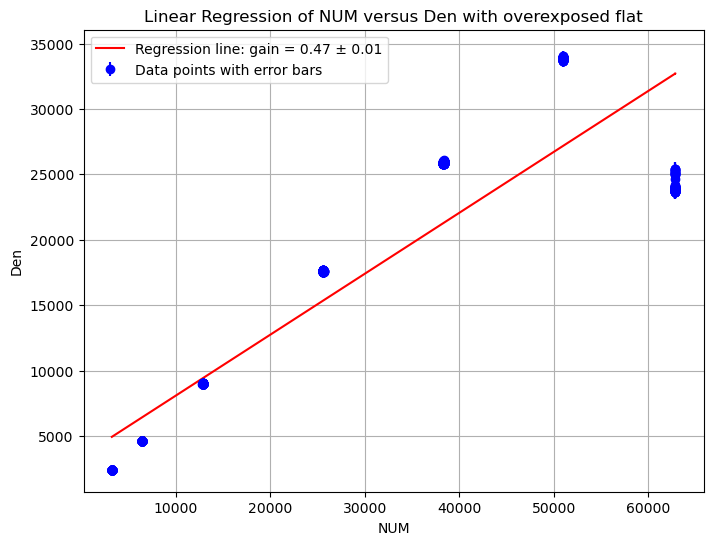

In [27]:
x = np.array(NUM, dtype=np.float64)
y = np.array(Den, dtype=np.float64)

# Compute regression slope (k) and intercept (b)
n = len(x)
mean_x = np.mean(x)
mean_y = np.mean(y)

k = np.sum((x - mean_x) * (y - mean_y)) / np.sum((x - mean_x) ** 2)
b = mean_y - k * mean_x

# Predicted values
y_pred = k * x + b  # Now this will work

# Residuals
residuals = y - y_pred

# Standard error of the slope
std_err = np.sqrt(np.sum(residuals**2) / (n - 2)) / np.sqrt(np.sum((x - mean_x) ** 2))

print(f"Slope (k) of the regression line: {k}")
print(f"Standard error of the slope: {std_err}")

# Plotting with error bars
plt.figure(figsize=(8, 6))

# Standard deviation of residuals as error bars
yerr = std_err * x  # Error should scale with x

plt.errorbar(x, y, yerr=yerr, fmt='o', color='blue', label='Data points with error bars')

# Plot regression line
plt.plot(x, k * x + b, color='red', label=f"Regression line: gain = {k:.2f} ± {std_err:.2f}")

# Add titles and labels
plt.title('Linear Regression of NUM versus Den with overexposed flat')
plt.xlabel('NUM')
plt.ylabel('Den')

# Add a legend
plt.legend()

# Show the plot with grid
plt.grid(True)
plt.show()

Slope (k) of the regression line: 1.5153677087377104
Standard error of the slope: 0.0009880534653295711


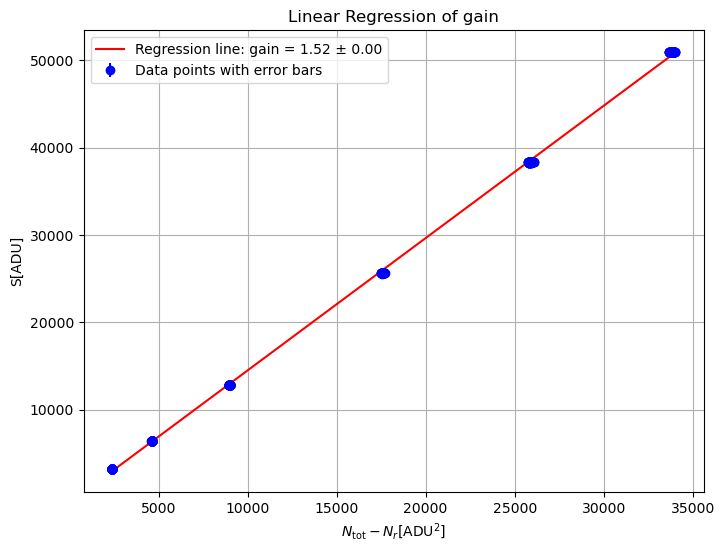

In [29]:
flat_shape = (510, 765)  # Assuming these are the correct dimensions
flat_accumulator = np.zeros(flat_shape)  # Accumulate pixel values for master bias
NUM = []
Den =[]
#flat = [np.zeros((510, 765)) for _ in range(7)]
#Meanflat = np.zeros(7)
#Exptime = np.zeros(7)
#Variances = np.zeros((7, 15))
#VAR = np.zeros(7)
# Loop through FITS files
for l in range(6):
    Mean = 0
    flatimages = []
    for i in range(15):
        filename = f"pyobs-20240528-0{705 + l * 15 + i:03d}-f00.fits"
        try:
            with fits.open(filename) as hdulist:
                hdu = hdulist[0]  # Access the primary HDU
                data = hdu.data.astype(np.float32)  # Ensure consistent data type
                flatimages.append(data)  # Append current bias frame to the list
                flat_accumulator += data  # Accumulate data for master bias
        except FileNotFoundError:
            print(f"File {filename} not found.")
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
        # Generate all possible pairs of bias frames
    combinations = itertools.combinations(flatimages, 2)

    # Empty list to store the variances
    standard = []
    mean_differences = []  # To store mean differences for each pair

    # Calculate the variance for each pair of bias frames
    for img1, img2 in combinations:
        Num = np.mean((img1 + img2)/2 - masterbias)  # Difference between the two images
        diff = img1 - img2
        mean_diff = np.mean(diff)  # Mean of the difference
        std = np.std(diff)  # Variance of the difference
        den = (std**2)/2 - read_out_noise
        # Append results to lists
        mean_differences.append(mean_diff)
        standard.append(std)
        NUM.append(Num)
        Den.append(den)
    # Ensure we have loaded images
if not flatimages:
    raise ValueError("No bias images loaded.")
y = np.array(NUM, dtype=np.float64)
x = np.array(Den, dtype=np.float64)

# Compute regression slope (k) and intercept (b)
n = len(x)
mean_x = np.mean(x)
mean_y = np.mean(y)

k = np.sum((x - mean_x) * (y - mean_y)) / np.sum((x - mean_x) ** 2)
b = mean_y - k * mean_x

# Predicted values
y_pred = k * x + b  # Now this will work

# Residuals
residuals = y - y_pred

# Standard error of the slope
std_err = np.sqrt(np.sum(residuals**2) / (n - 2)) / np.sqrt(np.sum((x - mean_x) ** 2))

print(f"Slope (k) of the regression line: {k}")
print(f"Standard error of the slope: {std_err}")

# Plotting with error bars
plt.figure(figsize=(8, 6))

# Standard deviation of residuals as error bars
yerr = std_err * x  # Error should scale with x

plt.errorbar(x, y, yerr=yerr, fmt='o', color='blue', label='Data points with error bars')

# Plot regression line
plt.plot(x, k * x + b, color='red', label=f"Regression line: gain = {k:.2f} ± {std_err:.2f}")

# Add titles and labels
plt.title('Linear Regression of gain')
plt.ylabel('S[ADU]')
plt.xlabel('$N_{\mathrm{tot}} - N_r$[ADU$^2$]')

# Add a legend
plt.legend()

# Show the plot with grid
plt.grid(True)
plt.show()

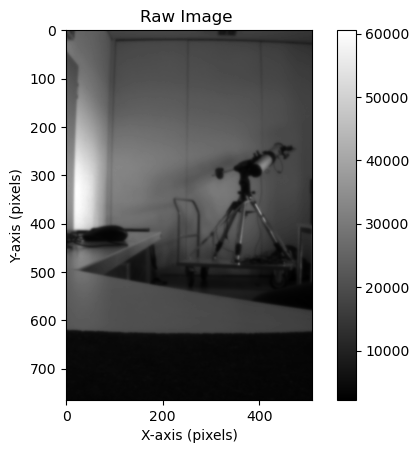

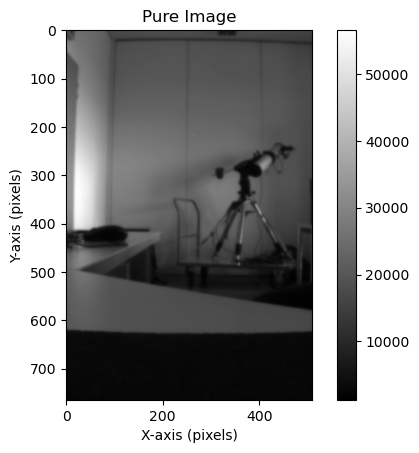

In [30]:
# Initialize arrays
Tel = np.zeros((510, 765))
Telpure = np.zeros((510, 765))

# Loop through 5 FITS files
for i in range(5):
    filename = f"pyobs-20240528-0{949+i:03d}-e00.fits"
    with fits.open(filename) as hdulist:
        hdu = hdulist[0]
        Tel += hdu.data
        Telpure += (hdu.data - bias - dark * hdu.header['EXPTIME'] / 300) / pureflat

# Average the images
Tel /= 5
Telpure /= 5

# Rotate images by 270° counterclockwise (or 90° clockwise)
Tel_rotated = np.rot90(Tel, k=3)
Telpure_rotated = np.rot90(Telpure, k=3)

# Plot rotated raw image
plt.imshow(Tel_rotated, cmap='gray')
plt.colorbar()
plt.title('Raw Image ')
plt.xlabel('X-axis (pixels)')
plt.ylabel('Y-axis (pixels)')
plt.show()

# Plot rotated pure image
plt.imshow(Telpure_rotated, cmap='gray')
plt.colorbar()
plt.title('Pure Image')
plt.xlabel('X-axis (pixels)')
plt.ylabel('Y-axis (pixels)')
plt.show()

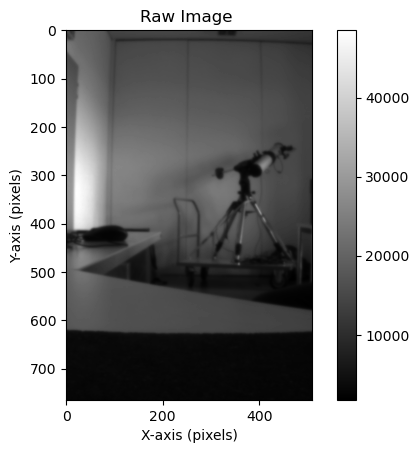

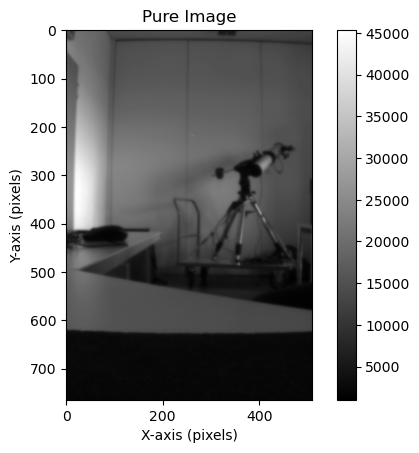

In [31]:
# Initialize arrays
Tel = np.zeros((510, 765))
Telpure = np.zeros((510, 765))

# Loop through 4 FITS files
for i in range(4):
    filename = f"pyobs-20240528-0{950+i:03d}-e00.fits"
    with fits.open(filename) as hdulist:
        hdu = hdulist[0]
        Tel += hdu.data
        Telpure += (hdu.data - bias - dark * hdu.header['EXPTIME'] / 300) / pureflat

# Average the images
Tel /= 5
Telpure /= 5

# Rotate images by 270° counterclockwise (or 90° clockwise)
Tel_rotated = np.rot90(Tel, k=3)
Telpure_rotated = np.rot90(Telpure, k=3)

# Plot rotated raw image
plt.imshow(Tel_rotated, cmap='gray')
plt.colorbar()
plt.title('Raw Image ')
plt.xlabel('X-axis (pixels)')
plt.ylabel('Y-axis (pixels)')
plt.show()

# Plot rotated pure image
plt.imshow(Telpure_rotated, cmap='gray')
plt.colorbar()
plt.title('Pure Image')
plt.xlabel('X-axis (pixels)')
plt.ylabel('Y-axis (pixels)')
plt.show()